In [18]:
%load_ext autoreload


%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Modelagem e Avaliação

| # | Seção |
|---|-------|
| 1.0 | Métricas Gerais de Avaliação |
| 2.0 | Entendendo a Regressão Logística |
| 3.0 | Carregamento dos Dados |
| 4.0 | Modelos Baseline (Threshold 0.50) |
| 5.0 | Otimização de Threshold |
| 6.0 | Tuning com Optuna e Feature Importance |
| 7.0 | Modelo Campeão e Exportação |


---

## 1.0) Métricas Gerais de Avaliação

### 1.1) Classe Positiva / Negativa

Basicamente, define se o evento ocorre (Sim/Não). Nesse caso, buscamos previsões binárias:

* **Classe Positiva (1):** Sucesso. `É o evento que tentamos prever` $\rightarrow$ Ocorrência de chuva.
* **Classe Negativa (0):** Insucesso. `O estado padrão` $\rightarrow$ Não ocorrência de chuva.

### 1.2) Score / Probabilidade

* É a chance (confiança do modelo) de um evento acontecer. É um valor contínuo entre `0` e `1`.

### 1.3) Threshold (Limiar de Corte)

* É a métrica de corte a partir da qual eu defino que a probabilidade do evento se torna uma **classe positiva**.
* **Exemplo:** Se defino um threshold de `0.7` para ocorrência de chuva, o modelo só prevê como positivo (Vai chover) caso a probabilidade entregue seja $\ge 0.7$.

---

### 1.4) A Matriz de Confusão

* **TP (VP):** Verdadeiro Positivo
* **FP:** Falso Positivo
* **TN (VN):** Verdadeiro Negativo
* **FN:** Falso Negativo


Nesse contexto, a matriz de decisão apresenta-se da seguinte forma:

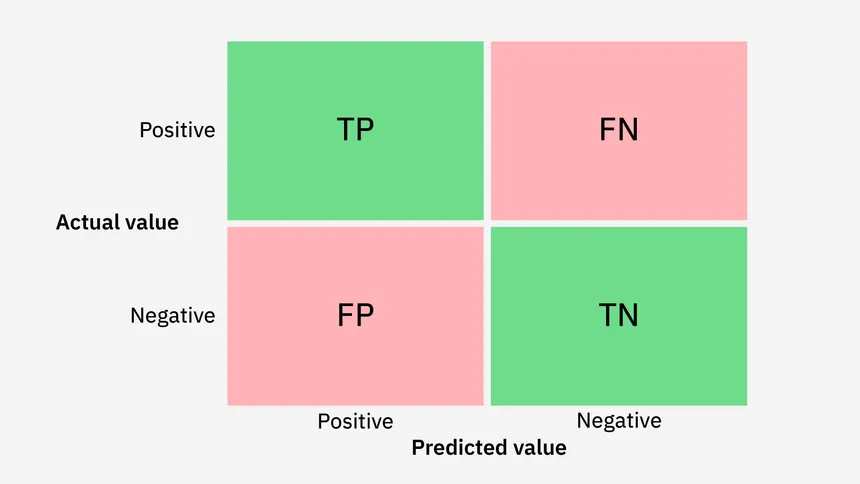

O objetivo é avaliar **como** o modelo erra, pois alguns modelos tendem a errar mais gerando falsos positivos, enquanto outros geram falsos negativos.

> *Nota prática:* Um modelo médico de triagem para internação precisaria minimizar ao máximo os **falsos negativos** (mandar para casa alguém que deveria ser internado).

---

### 1.5) Métricas Pontuais (Fixas em um Threshold)

#### Acurácia (Accuracy)

* É o total de acertos sobre o total de previsões do modelo.

$$\text{Acc} = \frac{VP + VN}{VP + VN + FP + FN}$$


* **Atenção:** Tome cuidado! Num cenário onde não chove em 80% dos dias, um "modelo burro" pode prever `0` (não chove) todos os dias e ainda assim terá 80% de acurácia.
* Classes **desbalanceadas** quebram a utilidade dessa métrica.

#### Precisão (Precision)

* Avalia a qualidade dos alarmes disparados. De todas as vezes em que o modelo disse "Vai Chover", em quantas ele realmente estava certo?

$$\text{Precision} = \frac{VP}{VP + FP}$$


* **Objetivo:** Minimizar o **Falso Positivo** (alarme falso).

#### Recall / Sensitivity (Sensibilidade)

* Avalia a capacidade de captura. De todos os dias em que **realmente choveu**, quantos o modelo conseguiu detectar?

$$\text{Recall} = \frac{VP}{VP + FN}$$


* **Objetivo:** Minimizar o **Falso Negativo** (omissão / deixar o evento passar).

#### Specificity (Especificidade)

* De todos os dias em que **não choveu**, quantos o modelo detectou corretamente como dias secos?

$$\text{Specificity} = \frac{VN}{VN + FP}$$


* A Taxa de Falsos Positivos (FPR) é definida como $1 - \text{Especificidade}$.

#### F1-Score

* É a média harmônica entre a *Precision* e o *Recall*. Costuma ser uma métrica muito mais segura para bases desbalanceadas.

$$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$


* Se a Precisão ou o Recall for muito ruim, o F1-Score despenca e aproxima-se de zero, penalizando o modelo.

---

### 1.6) Métricas Globais (Avaliam todos os Thresholds)

#### ROC-AUC

É uma métrica de área (Area Under the Curve) para avaliar a qualidade do modelo **independente do threshold adotado**. Equilibra a precisão entre as classes positiva e negativa.

* **Eixo X:** Taxa de Falsos Positivos (FPR = $1 - \text{Especificidade}$)
* **Eixo Y:** Taxa de Verdadeiros Positivos (TPR = Recall)
* **Como funciona:** O modelo pega o vetor de probabilidade via `.predict_proba()` e ordena os valores. A curva avalia todos os cenários:
* Começa com **Threshold = 1.0**: O modelo não prevê nada como positivo (TPR $= 0$ // FPR $= 0$).
* Vai diminuindo até o **Threshold = 0.0**: O modelo prevê tudo como positivo (TPR $= 1$ // FPR $= 1$).

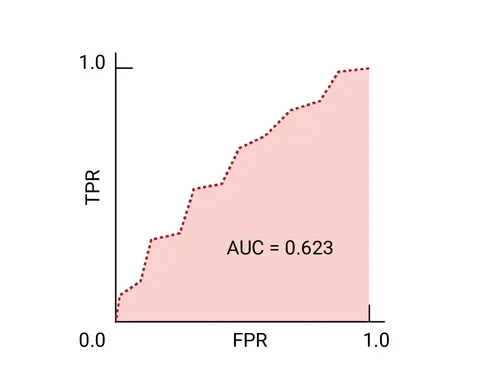

**Interpretação da Área (normalizada de 0 a 1):**

* **ROC-AUC < 0.5** $\rightarrow$ O modelo está invertido.
* **ROC-AUC = 0.5** $\rightarrow$ Pior caso possível (modelo 100% aleatório, igual jogar uma moeda).
* **ROC-AUC entre [0.7 - 0.8]** $\rightarrow$ Discriminação aceitável.
* **ROC-AUC entre [0.8 - 0.9]** $\rightarrow$ Excelente discriminação.
* **ROC-AUC > 0.9** $\rightarrow$ Modelo bom demais para ser verdade (verificar possibilidade de *data leakage*).

#### PR-AUC

* Semelhante ao ROC-AUC, mas prevê a qualidade focando estritamente na **classe positiva**.
* É o gráfico de **Precision** (Eixo Y) x **Recall** (Eixo X).
* Funciona da mesma forma: faz o `.predict_proba()` e varia o threshold. É ideal quando os dados são absurdamente desbalanceados.

#### KS

Mede a capacidade **máxima de separação** de um modelo em distanciar a população positiva da negativa.

* Avalia a Função de Distribuição Acumulada (FDA) das probabilidades previstas para os dias chuvosos ($F_1$) e dias sem chuva ($F_0$).

$$KS = \max \vert{}F_1(s) - F_0(s)\vert{}$$



**Interpretação (em %):**

* **$KS = 0\%$** $\rightarrow$ Modelo é equivalente ao acaso.
* **$KS < 20\%$** $\rightarrow$ Modelo muito fraco / sem utilidade prática.
* **$20\% \le KS < 30\%$** $\rightarrow$ Capacidade de separação razoável.
* **$30\% \le KS < 40\%$** $\rightarrow$ Bom modelo discriminador.
* **$40\% \le KS < 60\%$** $\rightarrow$ Excelente modelo de separação.
* **$KS > 60\%$** $\rightarrow$ Desempenho excepcionalmente alto (verificar se não há fuga de dados / *data leakage*).
* **$KS = 100\%$** $\rightarrow$ Separação perfeita.


In [19]:
# ── Paths ──────────────────────────────────────────────────────
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))

# ── Standard library ─────────────────────────────────────────────
import os
import warnings

# ── Third-party ─────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Scikit-Learn ─────────────────────────────────────────────────
from sklearn.model_selection import cross_val_predict, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import precision_recall_curve

# ── Project modules ──────────────────────────────────────────────
from utils import (
    avaliar_classificador,
    comparar_matrizes_cv,
    plot_feature_importance,
)

from src.pipeline import (
    preprocessor_enxuto,
    preprocessor_intermediario,
    preprocessor_completo_otimizado,
    preprocessor_completo_nulos,
    carregar_historico,
    carregar_oot,
)

from src.drift import feature_importance_pipeline

# ── Config ───────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')


---

## 2.0) Entendendo a Regressão Logística

A Regressão Logística é um modelo de classificação binária fundamentado na **função logística (curva sigmoide)**:

A equação geral que descreve essa transformação é:

$$p = \sigma(z) = \frac{1}{1 + e^{-z}}$$

Onde $z$ **não é a probabilidade final**, mas sim o valor contínuo (o *log-odds* ou combinação linear) gerado pela equação linear:

$$z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n$$

* **$z$ (ou $\hat{y}$ linear):** Pode assumir qualquer número real, de $-\infty$ a $+\infty$.
* **$\sigma(z)$ (Sigmoide):** "Esmaga" esse valor $z$ para o intervalo fechado entre $[0, 1]$, convertendo a combinação linear numa **probabilidade calibrada** ($p$).

### 2.1) L1 — Lasso 

* **Penalidade:** Penaliza o **módulo (valor absoluto)** dos coeficientes: $\lambda \sum \vert{}\beta_j\vert{}$.
* **Comportamento:** A força de atração em direção a zero é **constante** (derivada $=\pm 1$), com crescimento `linear`
* **Efeito nos coeficientes:** Consegue empurrar coeficientes irrelevantes **exatamente para zero** ($\beta_j = 0$).
* **Aplicação prática:** Atua como um **selecionador automático de features** (*sparsity*), ideal para cenários com `muitas variáveis redundantes` (como One-Hot Encoding com muitas categorias).

### 2.2) L2 — Ridge

* **Penalidade:** Penaliza o **quadrado** dos coeficientes: $\lambda \sum \beta_j^2$.
* **Comportamento:** Castiga de forma **desproporcionalmente severa os coeficientes grandes** (`crescimento quadrático`), mas a força desacelera conforme o coeficiente se aproxima de zero.
* **Efeito nos coeficientes:** Encolhe os pesos para valores minúsculos, mas **nunca zera nenhum coeficiente**.
* **Aplicação prática:** Excelente para lidar com **multicolinearidade** (variáveis fortemente correlacionadas), `distribuindo o impacto entre elas sem descartar nenhuma informação.`

### 2.3) C (Inverso da Regularização)

- Lembrando que a regularização (L1/L2/etc) busca o lambda tal que:

$$\text{Custo Total} = \text{Erro nos Dados (Loss)} + \lambda \cdot \text{Penalidade}(\beta)$$

É matematicamente o inverso da regularização:

$$C = \frac{1}{\lambda}$$

- **C baixo (0.001):** combate forte ao overfitting
- **C alto (100):** ignora a regularização, pode causar overfitting

### 2.4) Parâmetros Principais da `LogisticRegression` (Scikit-Learn)

A classe `sklearn.linear_model.LogisticRegression` oferece os seguintes parâmetros essenciais de configuração e ajuste:

* **`penalty`** (padrão: `'l2'`):
* Define o tipo de regularização aplicada para penalizar pesos excessivamente grandes e combater o *overfitting*.
* `'l2'` (Ridge): Encolhe os coeficientes sem zerá-los (ótimo para lidar com multicolinearidade).
* `'l1'` (Lasso): Força coeficientes irrelevantes exatamente a zero (útil como seleção automática de variáveis).
* `'elasticnet'`: Combinação ponderada de L1 e L2.
* `None`: Ajuste sem nenhuma regularização.


* **`C`** (padrão: `1.0`):
* É a **força inversa da regularização** ($C = \frac{1}{\lambda}$).
* Valores menores (ex: `C = 0.01`): Regularização mais forte $\rightarrow$ coeficientes menores, modelo mais simples (combate *overfitting*).
* Valores maiores (ex: `C = 100`): Regularização fraca $\rightarrow$ o modelo ajusta-se mais aos dados de treino.


* **`solver`** (padrão: `'lbfgs'`):
* O algoritmo numérico de otimização que encontra os melhores coeficientes $\beta$.
* `'lbfgs'`: Excelente para bases médias e suporta apenas `'l2'` ou `None`.
* `'liblinear'`: Bom para bases pequenas e suporta regularização `'l1'`.
* `'saga'`: Rápido para bases grandes e suporta todas as penalidades (`'l1'`, `'l2'`, `'elasticnet'`).


* **`class_weight`** (padrão: `None`):
* Trata bases com desbalanceamento de classes (como o caso de chuva $\approx 22\%$).
* `'balanced'`: Atribui pesos maiores aos erros cometidos na classe minoritária (chuva), compensando a discrepância de volume automaticamente.


* **`max_iter`** (padrão: `100`):
* Número máximo de iterações permitidas para o algoritmo convergir.
* Para dados tabulares climáticos com muitas variáveis codificadas, costuma-se aumentar para `1000` a fim de evitar o aviso `ConvergenceWarning`.


* **`fit_intercept`** (padrão: `True`):
* Define se o modelo deve calcular o termo independente $\beta_0$ (o viés/ponto de partida).


* **`random_state`**:
* Semente numérica para garantir que os resultados sejam reproduzíveis caso os solucionadores (`solver`) usem amostragem aleatória (como o `'saga'`).



---

## 3.0) Carregamento dos Dados


In [3]:
# Carrega os datasets histórico e OOT via src.pipeline

df_historico = carregar_historico()
df_oot = carregar_oot()

In [4]:
# Define a variável alvo e o threshold inicial

target = 'RainTomorrow'

threshold = 0.5

In [26]:
# Separa features (X) e target (y) para histórico e OOT

# Histórico (para Treinar e Validar)
X_hist = df_historico.drop(columns=[target])
y_hist = df_historico[target]



---

## 4.0) Modelos Baseline (Threshold 0.50)

### 4.1) Definição dos Modelos


In [6]:
# Dicionário das 4 pipelines completas com regressão logística

modelos = {
    'Enxuta': Pipeline([
        ('prep', preprocessor_enxuto),
        ('clf', LogisticRegression(max_iter=1000, random_state=14))
    ]),
    'Intermediária': Pipeline([
        ('prep', preprocessor_intermediario),
        ('clf', LogisticRegression(max_iter=1000, random_state=14))
    ]),
    'Completa Otimizada': Pipeline([
        ('prep', preprocessor_completo_otimizado),
        ('clf', LogisticRegression(max_iter=1000, random_state=14))
    ]),
    'Completa c/ Nulos': Pipeline([
        ('prep', preprocessor_completo_nulos),
        ('clf', LogisticRegression(max_iter=1000, random_state=14))
    ])
}

# Thresholds iniciais (0.5 para todos)
vetor_05 = [0.5 for i in range(len(modelos))]
threshold_dicionario = dict(zip(modelos.keys(), vetor_05))

### 4.2) Avaliação Baseline (CV = 5)


In [7]:
# Avalia cada modelo baseline com validação cruzada (threshold = 0.50)

for nome, modelo in modelos.items():

    avaliar_classificador(
        modelo, 
        X_hist, 
        y_hist, 
        nome_modelo=nome, 
        cv=5, 
        threshold=threshold_dicionario, 
        tipo_metricas='todas'  
    )



 ENXUTA (CV = 5 | Threshold = 0.5000)
--------------------------------------------------------------------------------------------
  Métrica    | Treino     | Validação  | Gap (V-T)  | IC 95% (Validação)      | Margem (±)
  ---------- | ---------- | ---------- | ---------- | ----------------------- | ----------
  Accuracy   |     0.8377 |     0.8377 |    -0.0000 | [   0.8340,    0.8414] |  ± 0.0037
  Precision  |     0.7164 |     0.7164 |    -0.0000 | [   0.7014,    0.7314] |  ± 0.0150
  Recall     |     0.4625 |     0.4623 |    -0.0002 | [   0.4518,    0.4727] |  ± 0.0105
  F1-Score   |     0.5621 |     0.5619 |    -0.0002 | [   0.5518,    0.5720] |  ± 0.0101
  ROC-AUC    |     0.8454 |     0.8454 |    -0.0001 | [   0.8427,    0.8481] |  ± 0.0027
  PR-AUC     |     0.6623 |     0.6622 |    -0.0001 | [   0.6546,    0.6699] |  ± 0.0077
  KS         |     0.5296 |     0.5309 |    +0.0013 | [   0.5238,    0.5380] |  ± 0.0071


 INTERMEDIÁRIA (CV = 5 | Threshold = 0.5000)
----------------

> Todos os `modelos foram extremamente robustos ( sem indícios de overfitting)` e, impressionantemente, os modelos mais complexos
> progressivamente obtiveram resultados melhores que os mais simples.
>
> **De fato não foi um fator esperado pois, a princípio, o aumento da assertividade do modelo causaria uma explosão na dimensionalidade ( `Já que foi preciso realizar diversos one-hot-encondings`) e de fato, os modelos completos precisam de um poder de processamento muito maior**, demoram muito mais pra ser processados
>
> Veja que o melhor modelo **Completo c/Nulos** obteve um ROC-AUC de 0.87, alta acurácia (0.8485)
> e precisão (0.7327), mas veja que o Recall (0.5150) e PR-AUC 0.7061
>
> Ou seja, o modelo acerta bem, mas possui um problema com **falsos negativos**.
> 
> O modelo é bem conservador, está arriscado pouco. Podemos melhorar isso pela mudança do `threshold`


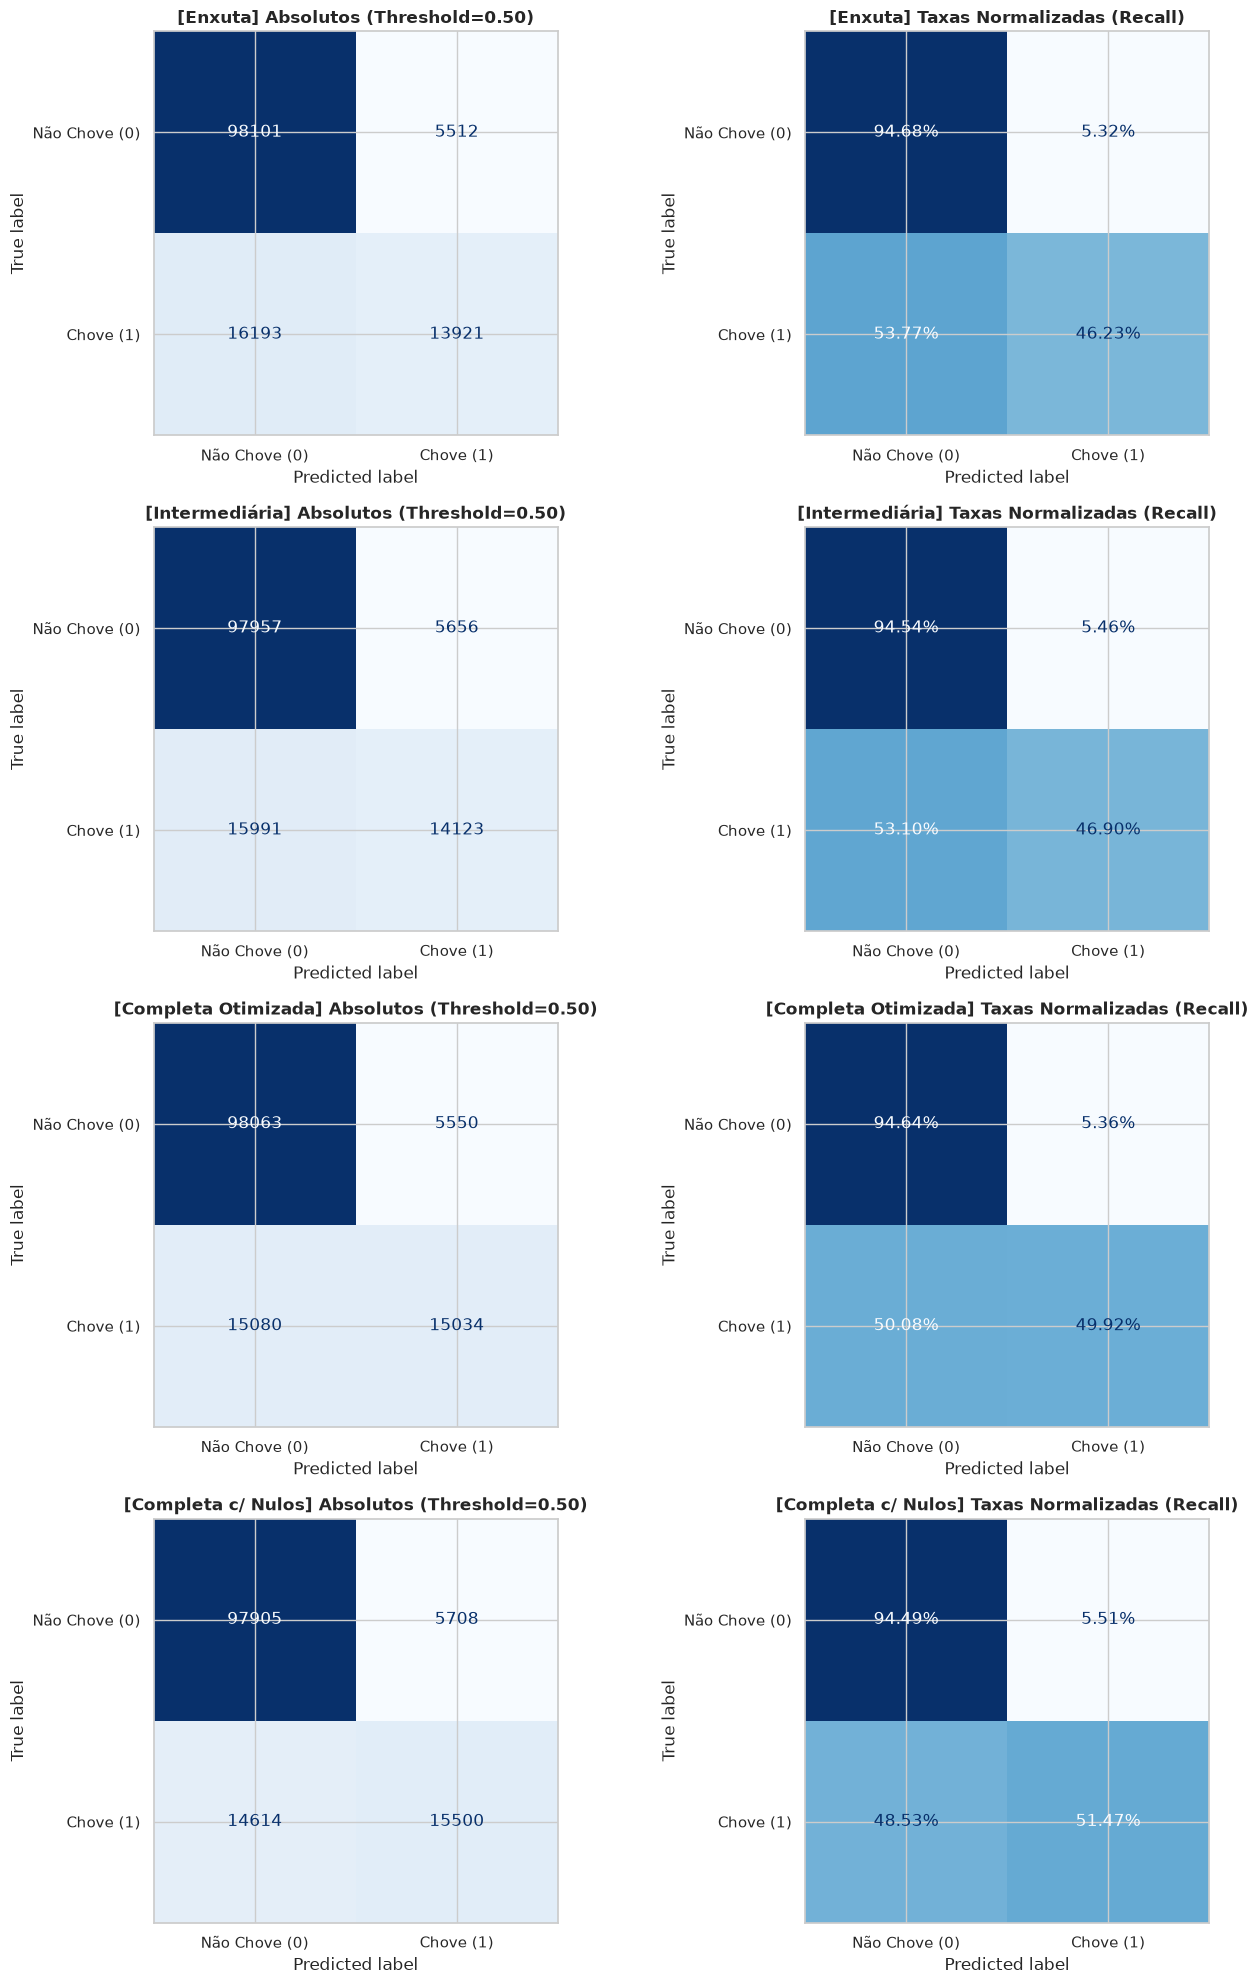

In [8]:
# Plota as matrizes de confusão dos modelos baseline

comparar_matrizes_cv(modelos, threshold_dicionario, X_hist, y_hist, cv=5)

> * **Assimetria de Classes ($78\%$ (0) vs. $22\%$(1)):** O desbalanceamento natural da base faz
>   com que o corte padrão de `0.50` force os modelos a favorecerem a classe majoritária (`Não Chove`).
>
> * **Omissão (Muitos Falsos Negativos):** Todos os modelos sofrem com um número crítico de
>   **Falsos Negativos**. Todos os modelos se apresentam omissos e erram muito em apresentar dias
>   reais de chuva com a previsão de **não chuva**, ou seja, o modelo é omisso.
>
>   O modelo **raramente emite alarmes falsos** (baixo volume de `Falsos Positivos`), mas erra
>   gravemente por **omissão**, falhando em alertar quase metade dos eventos de tempestade.
>
>   `Devemos buscar um threshold que conserte isso, de preferência um mais baixo que 0.5`.



---

## 5.0) Otimização de Threshold

### 5.1) Busca do Threshold Ótimo

**Estratégia:** Varrer a curva PR-AUC e buscar o máximo F1-score ao se varrer o threshold.


In [9]:
# Stratified K-Fold (manter proporções do target)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Dicionário para guardar os melhores thresholds
melhores_threshold = {}

print("="*60)
print(" OTIMIZAÇÃO DE THRESHOLD (MAXIMIZANDO F1-SCORE)")
print("="*60)

for nome, modelo in modelos.items():

    # Obtém probabilidades via cross-validation
    y_probs = cross_val_predict(
        modelo, 
        X_hist, 
        y_hist, 
        cv=skf, 
        method='predict_proba', 
        n_jobs=-1
    )[:, 1]

    # Calcula precisão e recall para todos os pontos de corte possíveis
    precisions, recalls, thresholds = precision_recall_curve(y_hist, y_probs)

    # Adicionado + 1e-10 para evitar ZeroDivisionError
    f1_scores = (2 * precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

    # Identifica o melhor índice e o threshold correspondente
    melhor_idx = np.argmax(f1_scores)
    melhor_t = thresholds[melhor_idx]
    
    # Salva para usar nas matrizes depois
    melhores_threshold[nome] = melhor_t

    # Busca o F1 no limiar de 0.50 para comparação
    idx_padrao = np.argmin(np.abs(thresholds - 0.50))
    
    print(f"[{nome}]")
    print(f"  Threshold Padrão (0.50) -> F1: {f1_scores[idx_padrao]:.4f}")
    print(f"  Threshold Ótimo ({melhor_t:.4f}) -> F1 Máximo: {f1_scores[melhor_idx]:.4f}\n")

 OTIMIZAÇÃO DE THRESHOLD (MAXIMIZANDO F1-SCORE)
[Enxuta]
  Threshold Padrão (0.50) -> F1: 0.5619
  Threshold Ótimo (0.3235) -> F1 Máximo: 0.6129

[Intermediária]
  Threshold Padrão (0.50) -> F1: 0.5661
  Threshold Ótimo (0.3137) -> F1 Máximo: 0.6185

[Completa Otimizada]
  Threshold Padrão (0.50) -> F1: 0.5931
  Threshold Ótimo (0.3374) -> F1 Máximo: 0.6338

[Completa c/ Nulos]
  Threshold Padrão (0.50) -> F1: 0.6040
  Threshold Ótimo (0.3175) -> F1 Máximo: 0.6420



### 5.2) Matrizes de Confusão com Threshold Ótimo


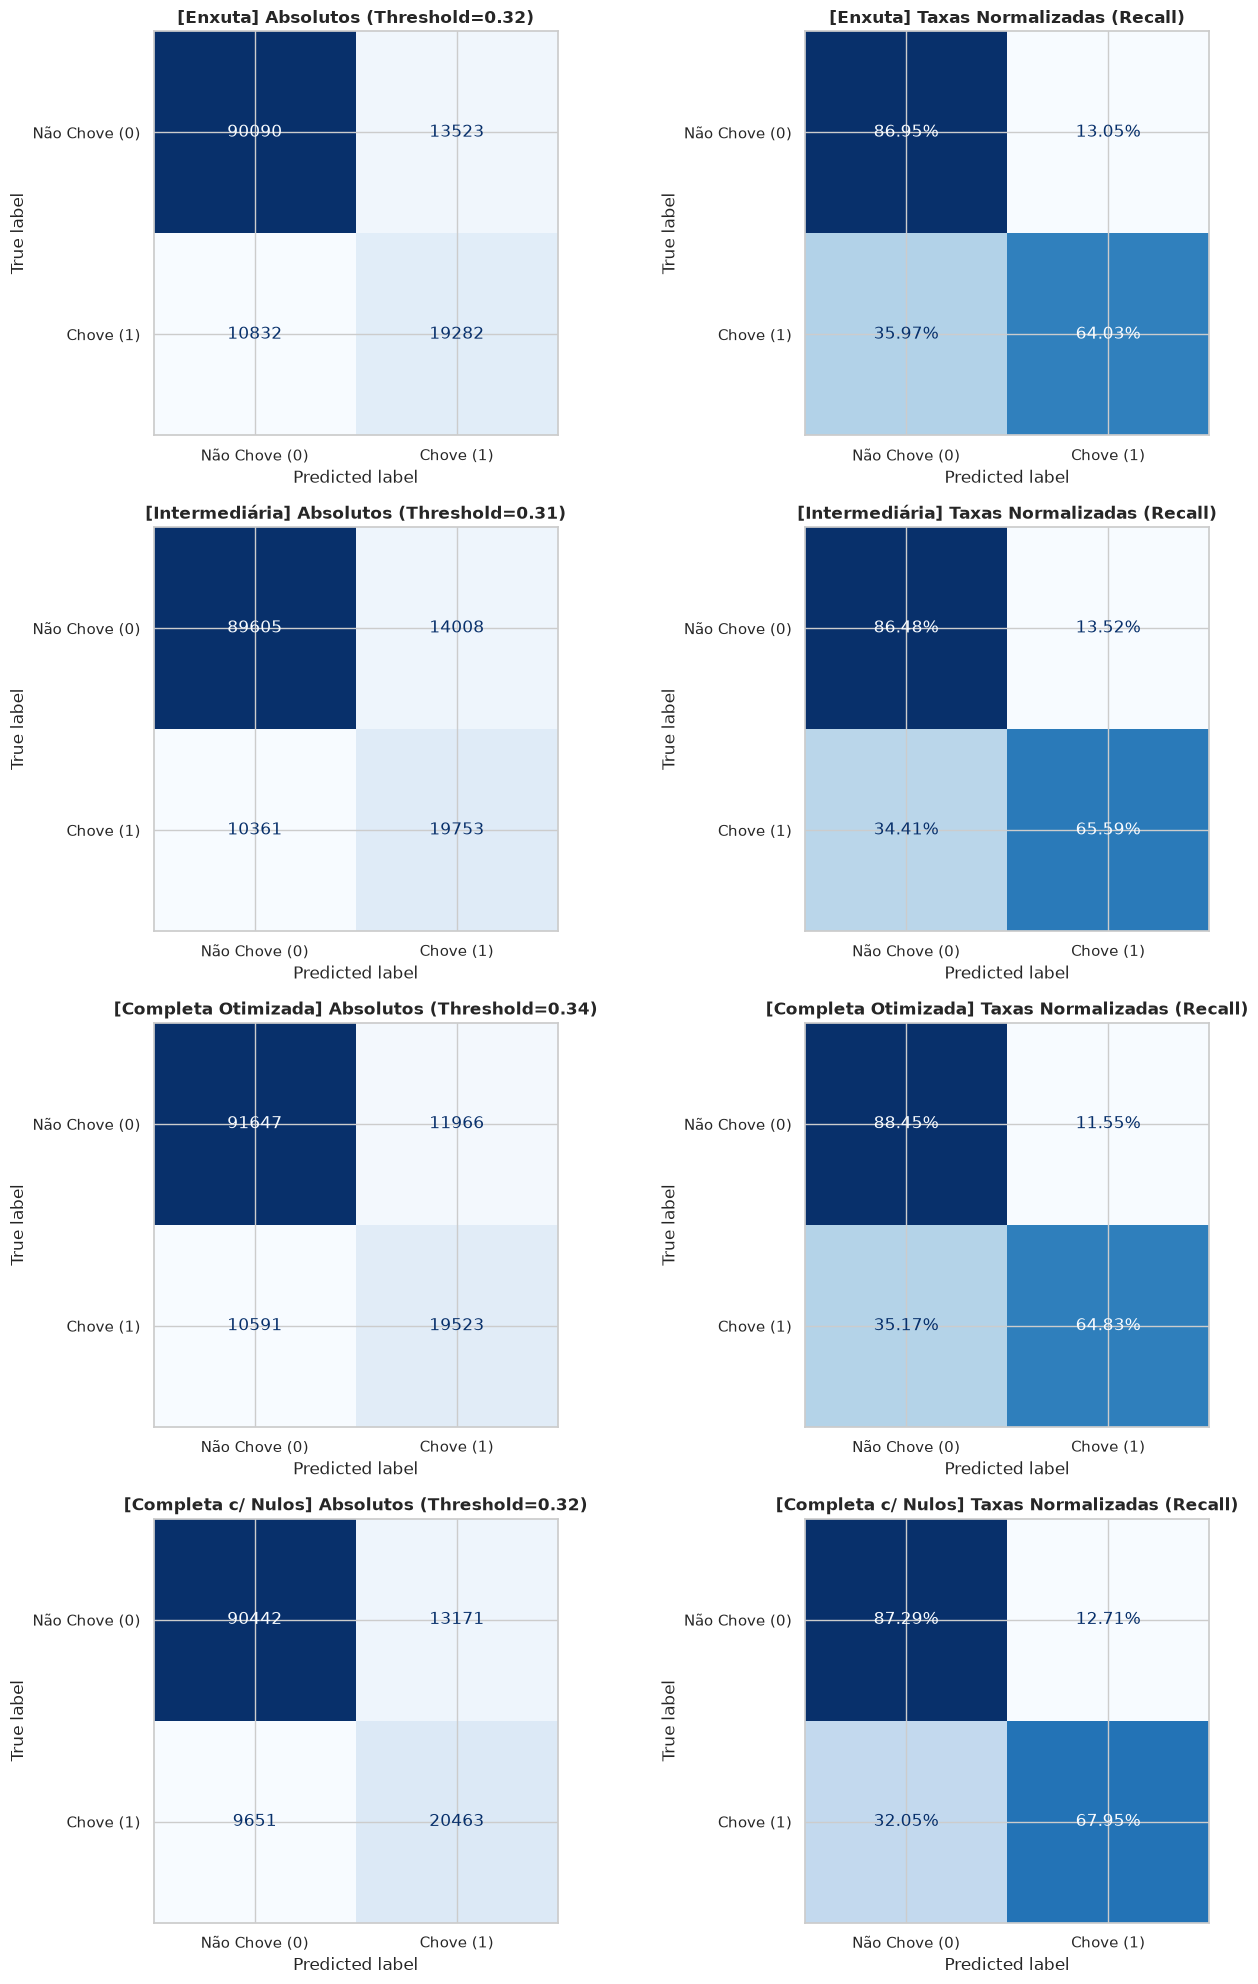

In [10]:
comparar_matrizes_cv(modelos,melhores_threshold, X_hist, y_hist, cv=5)

### 5.3) Reavaliação com Threshold Ótimo


>
>
> Veja que os modelos estão mais consistentes, mas ainda sim, ele  é `bem conservador` e erra **frequentemente com falsos negativos**
>

In [11]:
# Reavalia os modelos baseline usando os thresholds otimizados

for nome, modelo in modelos.items():

    avaliar_classificador(
        modelo, 
        X_hist, 
        y_hist, 
        nome_modelo=nome, 
        cv=5, 
        threshold= melhores_threshold, 
        tipo_metricas='dependentes'  
    )



 ENXUTA (CV = 5 | Threshold = 0.3235)
--------------------------------------------------------------------------------------------
  Métrica    | Treino     | Validação  | Gap (V-T)  | IC 95% (Validação)      | Margem (±)
  ---------- | ---------- | ---------- | ---------- | ----------------------- | ----------
  Accuracy   |     0.8178 |     0.8179 |    +0.0000 | [   0.8147,    0.8211] |  ± 0.0032
  Precision  |     0.5877 |     0.5878 |    +0.0000 | [   0.5806,    0.5949] |  ± 0.0071
  Recall     |     0.6400 |     0.6403 |    +0.0002 | [   0.6291,    0.6514] |  ± 0.0112
  F1-Score   |     0.6128 |     0.6129 |    +0.0001 | [   0.6059,    0.6199] |  ± 0.0070


 INTERMEDIÁRIA (CV = 5 | Threshold = 0.3137)
--------------------------------------------------------------------------------------------
  Métrica    | Treino     | Validação  | Gap (V-T)  | IC 95% (Validação)      | Margem (±)
  ---------- | ---------- | ---------- | ---------- | ----------------------- | ----------
  Accura


---

## 6.0) Tuning com Optuna

### 6.1) Busca de Hiperparâmetros

Buscando os melhores hiperparâmetros com Optuna.

Vamos buscar o melhor PR-AUC, já que foca tanto na predição da classe positiva como da negativa.


In [ ]:
melhores_hiperparametros = {}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("="*60)
print(" INICIANDO OPTUNA PARA OS MODELOS (Foco: PR-AUC)")
print("="*60)

for nome, modelo in modelos.items():
    print(f"...Otimizando o modelo: {modelo}")

    #isolando o modelo com a função clone
    pipeline_atual = clone(modelo)


    def objetivo(trial):

            #solver algoritmo da regressão:
            #liblinear --> ideal para bases pequenas
            #saga --> ideal para bases grandes
            solver = trial.suggest_categorical('clf__solver', ['liblinear', 'saga'])

            #penalty adciona a penalidade (l1 ou l2)
        
            penalty = trial.suggest_categorical('clf__penalty', ['l1', 'l2'])

            #inverso da regularização
            # C alto --> baixa regularização, alto risco de overfitting, modelo se adapta fortemente aos dados
            # C baixo --> alta regularização, baixo risco de overfitting, escolhe as melhores features

            C = trial.suggest_float('clf__C', 1e-4, 1e2, log=True)

            # busca dar peso as classes da previsão --> o balanceado busca dar uma boa precisão tanto pra classe 1 e zero.
            class_weight = trial.suggest_categorical('clf__class_weight', [None, 'balanced'])
            
            pipeline_atual.set_params(
                clf__solver=solver,
                clf__penalty=penalty,
                clf__C=C,
                clf__class_weight=class_weight,
                clf__max_iter=1000
            )
            
            scores = cross_val_score(
                pipeline_atual, 
                X_hist, 
                y_hist, 
                cv=skf, 
                scoring='average_precision', 
                n_jobs=-1
            )
            return scores.mean()

    print("Iniciando a busca por hiperparâmetros (Foco em PR-AUC)...")
    estudo_lr = optuna.create_study(direction='maximize', study_name="Tuning_Regressao_Logistica")

    # Executa 40 tentativas de otimização
    estudo_lr.optimize(objetivo, n_trials=40)

# Resultados
print("\n" + "="*60)
print(f" Melhor PR-AUC alcançado no CV: {estudo_lr.best_value:.4f}")
print("Melhores Hiperparâmetros encontrados:")
for chave, valor in estudo_lr.best_params.items():
    print(f" -> {chave.replace('clf__', '')}: {valor}")
print("="*60)
    

 INICIANDO OPTUNA PARA OS MODELOS (Foco: PR-AUC)
...Otimizando o modelo: Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num_robust',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['Humidity3pm', 'Pressure3pm',
                                                   'WindGustSpeed',
                                                   'MaxTemp']),
                                                 ('num_log',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=0.0,
                                              

### 6.2) Modelos Ajustados (Tuned)


In [12]:
# Reconstrói os modelos com os melhores hiperparâmetros encontrados pelo Optuna

modelos_tunned = {
    'Enxuta': Pipeline([
        ('prep', preprocessor_enxuto),
        ('clf', LogisticRegression(
            solver='liblinear', 
            penalty='l1', 
            C=93.95337064926001, 
            class_weight=None, 
            max_iter=1000, 
            random_state=14
        ))
    ]),
    'Intermediária': Pipeline([
        ('prep', preprocessor_intermediario),
        ('clf', LogisticRegression(
            solver='liblinear', 
            penalty='l1', 
            C=93.95337064926001, 
            class_weight=None, 
            max_iter=1000, 
            random_state=14
        ))
    ]),
    'Completa Otimizada': Pipeline([
        ('prep', preprocessor_completo_otimizado),
        ('clf', LogisticRegression(
            solver='liblinear', 
            penalty='l1', 
            C=93.95337064926001, 
            class_weight=None, 
            max_iter=1000, 
            random_state=14
        ))
    ]),
    'Completa c/ Nulos': Pipeline([
        ('prep', preprocessor_completo_nulos),
        ('clf', LogisticRegression(
            solver='liblinear', 
            penalty='l1', 
            C=93.95337064926001, 
            class_weight=None, 
            max_iter=1000, 
            random_state=14
        ))
    ])
}

### (6.3) Avaliação dos Modelos Tuned


In [ ]:
# Avalia os modelos tuned com todas as métricas (thresholds otimizados)

for nome, modelo in modelos_tunned.items():

    avaliar_classificador(
        modelo, 
        X_hist, 
        y_hist, 
        nome_modelo=nome, 
        cv=5, 
        threshold=melhores_threshold, 
        tipo_metricas='todas'  
    )



 ENXUTA (CV = 5 | Threshold = 0.3235)
--------------------------------------------------------------------------------------------
  Métrica    | Treino     | Validação  | Gap (V-T)  | IC 95% (Validação)      | Margem (±)
  ---------- | ---------- | ---------- | ---------- | ----------------------- | ----------
  Accuracy   |     0.8178 |     0.8179 |    +0.0000 | [   0.8146,    0.8211] |  ± 0.0032
  Precision  |     0.5877 |     0.5877 |    +0.0000 | [   0.5806,    0.5949] |  ± 0.0072
  Recall     |     0.6400 |     0.6402 |    +0.0002 | [   0.6291,    0.6514] |  ± 0.0112
  F1-Score   |     0.6128 |     0.6129 |    +0.0001 | [   0.6059,    0.6199] |  ± 0.0070
  ROC-AUC    |     0.8454 |     0.8454 |    -0.0001 | [   0.8427,    0.8481] |  ± 0.0027
  PR-AUC     |     0.6623 |     0.6622 |    -0.0001 | [   0.6546,    0.6699] |  ± 0.0077
  KS         |     0.5296 |     0.5310 |    +0.0014 | [   0.5239,    0.5380] |  ± 0.0071


 INTERMEDIÁRIA (CV = 5 | Threshold = 0.3137)
----------------

### 6.4) Features mais importantes — Modelo Campeão

,Feature,Importancia,Direcao
0,Location_MountGinini,1.691494,-
1,Humidity3pm,1.650448,+
2,Pressure3pm,1.632479,-
3,Location_Wollongong,1.560911,-
4,Location_Townsville,1.510572,-
5,Location_Darwin,1.321895,-
6,Location_Hobart,1.290997,-
7,Location_Katherine,1.274434,-
8,Location_MelbourneAirport,1.235856,-
9,Location_NorahHead,1.225558,-


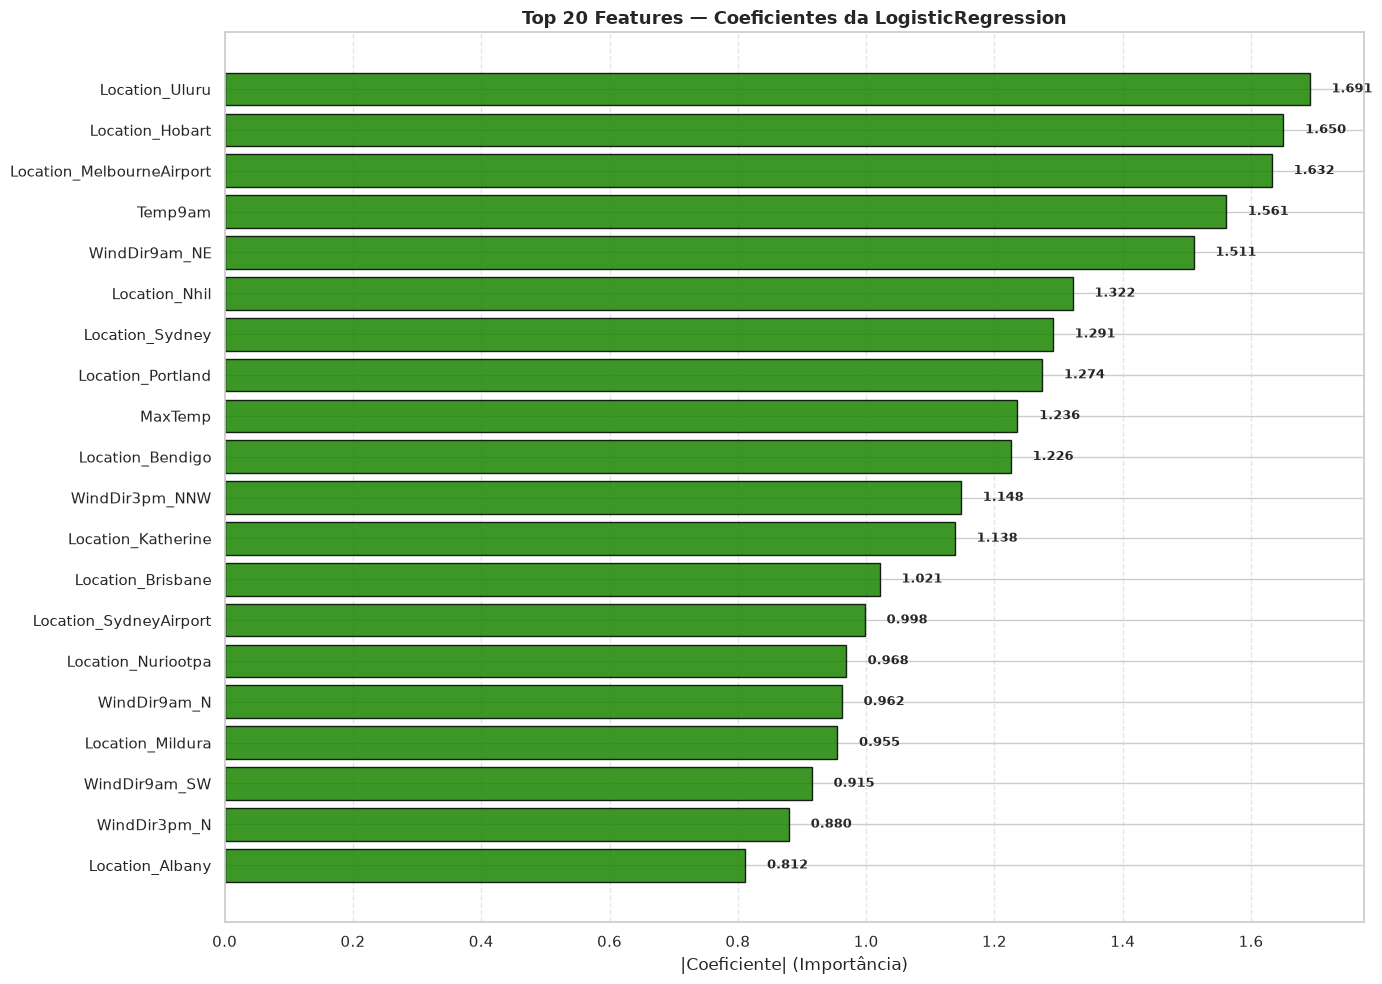

In [20]:
# Treina o modelo campeão para análise de coeficientes
nome_campeao = 'Completa c/ Nulos'
modelo_final = clone(modelos_tunned[nome_campeao])
modelo_final.fit(X_hist, y_hist)

# Extrai importância das features e exibe tabela
df_imp = feature_importance_pipeline(modelo_final, top_n=20)
display(df_imp)

# Gráfico de importância (|coeficientes|)
feature_names = feature_importance_pipeline(modelo_final, top_n=999)['Feature'].tolist()
plot_feature_importance(
    modelo_final,
    feature_names=feature_names,
    top_n=20,
    titulo='Top 20 Features — Coeficientes da LogisticRegression',
    cor="#1B8500",
    xlabel='|Coeficiente| (Importância)',
    figsize=(14, 10),
)

>
> **Veja que à despeito do aumento da dimensionalidade, as localizações desempenham um grande impacto no modelo**
>


### 6.5) Features mais importantes — Modelo Intermediário

,Feature,Importancia,Direcao
0,Humidity3pm,1.665812,+
1,WindGustSpeed,0.714632,+
2,Pressure3pm,0.536248,-
3,WindGustDir_N,0.527625,+
4,WindGustDir_NNW,0.468412,+
5,WindGustDir_NW,0.390660,+
6,WindSpeed3pm,0.328589,-
7,WindGustDir_WNW,0.269043,+
8,WindGustDir_NNE,0.189999,+
9,WindGustDir_W,0.188246,+


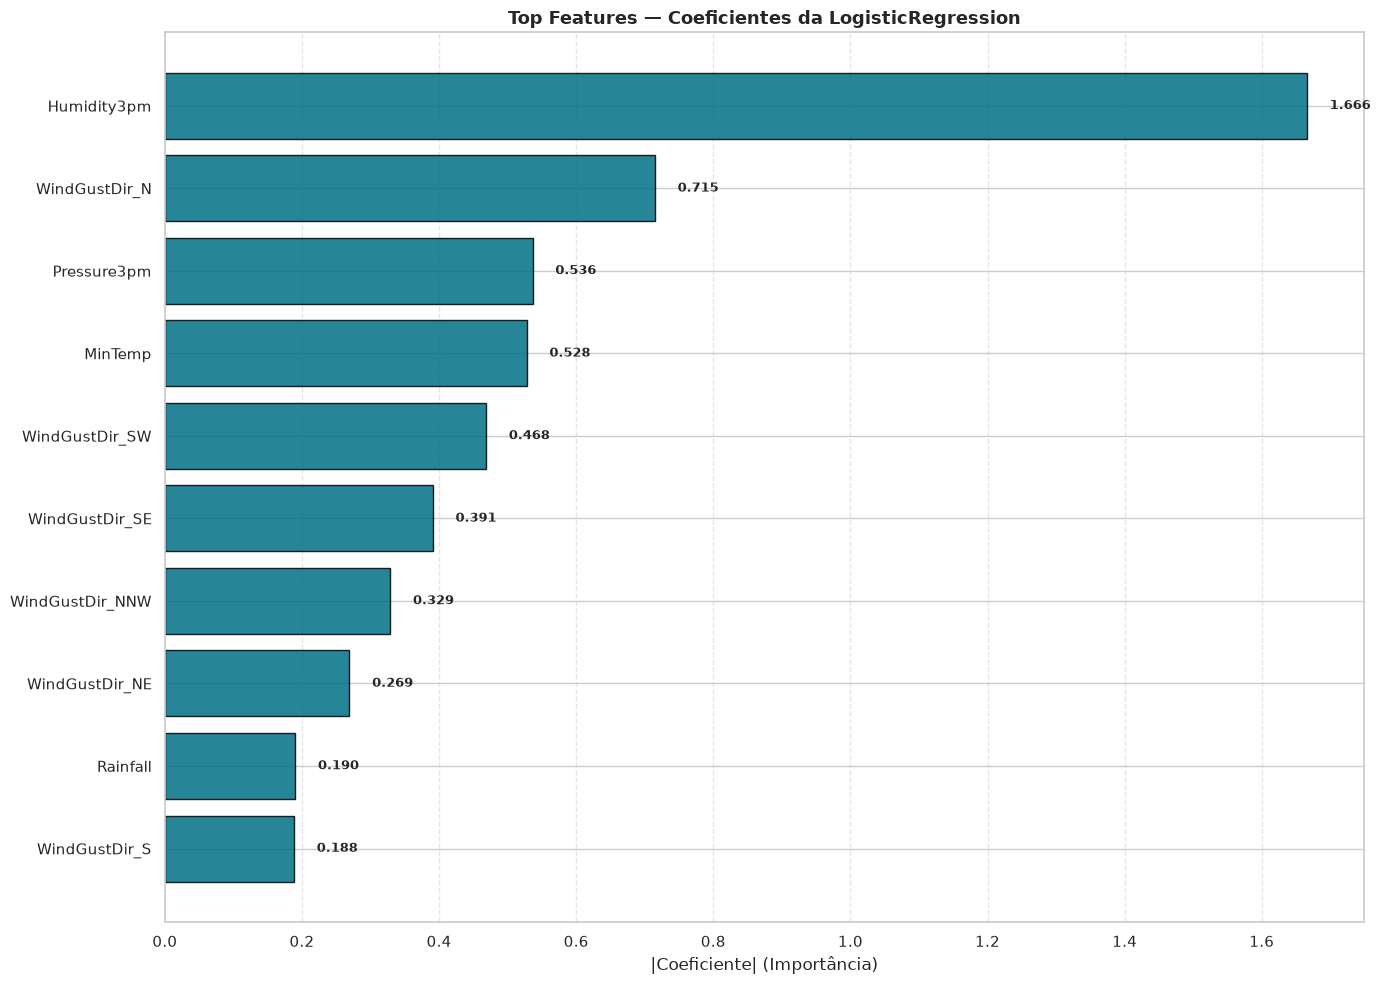

In [23]:
# Treinando um modelo numérico
nome_campeao = 'Intermediária'
modelo_final = clone(modelos_tunned[nome_campeao])
modelo_final.fit(X_hist, y_hist)

# Extrai importância das features e exibe tabela
df_imp = feature_importance_pipeline(modelo_final, top_n=20)
display(df_imp)

# Gráfico de importância (|coeficientes|)
feature_names = feature_importance_pipeline(modelo_final, top_n=999)['Feature'].tolist()
plot_feature_importance(
    modelo_final,
    feature_names=feature_names,
    top_n=10,
    titulo='Top Features — Coeficientes da LogisticRegression',
    cor="#007185",
    xlabel='|Coeficiente| (Importância)',
    figsize=(14, 10),
)

> **Features mais interessantes para o modelo:**
>
> Humidade, Direção do Vento, Pressão, Temperatura

## 7.0) Conclusões: Otimização e Calibração

* **Teto do Modelo Linear:** A otimização via *Optuna* trouxe ganhos **muito pequenos** nas métricas independentes (PR-AUC estabilizado em **aproximadamente 76%** ). Isso é um diagnóstico positivo: comprova que os `tratamentos de features` e definição dos `melhores thresholds` já era excelente e que a Regressão Logística atingiu o seu limite matemático para este problema.

* **O Verdadeiro Ganho Operacional:** O salto real de performance veio da calibração do *Threshold* (de $0.50$ para $\approx 0.32$). Essa regra de negócio **recuperou +16% de Recall** no modelo `Completa c/ Nulos`, passando a identificar $67.5\%$ dos eventos de chuva reais, mitigando severamente a omissão (Falsos Negativos).

* **Generalização Robusta:** O *gap* entre treino e validação em todas as métricas é praticamente zero. O modelo não sofre de *overfitting* e entregará resultados idênticos em produção.


---

## 8.0) Modelo Campeão e Exportação


In [14]:
# Seleciona e treina o modelo campeão com 100% dos dados históricos

nome_campeao = 'Completa c/ Nulos'
modelo_campeao = modelos_tunned[nome_campeao]
threshold_campeao = melhores_threshold[nome_campeao] 

print("="*60)
print(f" TREINANDO MODELO CAMPEÃO: [{nome_campeao}]")
print("="*60)

# Treinando o modelo campeão com 100% dos dados
modelo_campeao.fit(X_hist, y_hist)

# Exporta o pacote joblib
artefato_exportacao = {
    'modelo_nome': nome_campeao,
    'modelo': modelo_campeao,
    'threshold': threshold_campeao 
}

nome_arquivo = 'modelo.joblib'

# Salva o artefato em ../artifacts/
caminho_modelo = os.path.join('..','artifacts', nome_arquivo)
joblib.dump(artefato_exportacao, caminho_modelo)

print("\n" + "="*60)
print(f"Melhor modelo salvo como: '{nome_arquivo}'")
print(f"Threshold salvo junto: {threshold_campeao:.4f}")
print("="*60)

 TREINANDO MODELO CAMPEÃO: [Completa c/ Nulos]

Melhor modelo salvo como: 'modelo.joblib'
Threshold salvo junto: 0.3175
